<a href="https://colab.research.google.com/github/muru9031/DS_Day01_51_Construction_Delay/blob/main/DS_Day01_51_Construction_Delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# CELL 1: GENERATE REALISTIC DATASET (.CSV)
# ==========================================
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

categories = ['Roads & Highways', 'Bridges & Flyovers', 'Commercial Buildings', 'Metro & Rail', 'Water Infrastructure']
sizes = ['Small', 'Medium', 'Large']
material_status = ['On-Time', 'Slight Delay', 'Severe Delay']
weathers = ['Clear', 'Rainy', 'Extreme Heat', 'Stormy']
contractors = ['Contractor_A', 'Contractor_B', 'Contractor_C', 'Contractor_D']
milestones = ['1_Planning', '2_Foundation', '3_Structural', '4_MEP_Finishing', '5_Handover']

data = {
    'Project_ID': [f'PROJ_{1001+i}' for i in range(n)],
    'Project_Category': np.random.choice(categories, n, p=[0.25, 0.20, 0.25, 0.15, 0.15]),
    'Project_Size': np.random.choice(sizes, n, p=[0.3, 0.45, 0.25]),
    'Material_Delivery': np.random.choice(material_status, n, p=[0.45, 0.35, 0.20]),
    'Weather': np.random.choice(weathers, n, p=[0.50, 0.25, 0.15, 0.10]),
    'Contractor': np.random.choice(contractors, n, p=[0.30, 0.25, 0.25, 0.20]),
    'Milestone': np.random.choice(milestones, n, p=[0.15, 0.20, 0.30, 0.20, 0.15])
}

df_gen = pd.DataFrame(data)

# Size base panni Budget (in Crores) matrum Workforce generate panrom
size_budget = {'Small': (10, 50), 'Medium': (51, 200), 'Large': (201, 800)}
size_workforce = {'Small': (30, 100), 'Medium': (101, 350), 'Large': (351, 1000)}

df_gen['Budget'] = df_gen['Project_Size'].apply(lambda x: np.round(np.random.uniform(*size_budget[x]), 2))
df_gen['Workforce'] = df_gen['Project_Size'].apply(lambda x: np.random.randint(*size_workforce[x]))

# Milestone base panni Planned Progress (%)
milestone_progress = {
    '1_Planning': (10, 20),
    '2_Foundation': (21, 40),
    '3_Structural': (41, 70),
    '4_MEP_Finishing': (71, 90),
    '5_Handover': (91, 100)
}
df_gen['Planned_Progress'] = df_gen['Milestone'].apply(lambda x: np.round(np.random.uniform(*milestone_progress[x]), 1))

# Operational causes base panni Delay (Progress Gap) calculate panrom
delay = np.random.normal(2, 2, n)
delay += df_gen['Material_Delivery'].map({'On-Time': 0, 'Slight Delay': 8, 'Severe Delay': 18})
delay += df_gen['Weather'].map({'Clear': 0, 'Extreme Heat': 3, 'Rainy': 7, 'Stormy': 12})
delay += df_gen['Milestone'].map({'1_Planning': 1, '2_Foundation': 4, '3_Structural': 9, '4_MEP_Finishing': 7, '5_Handover': 3})
delay += df_gen['Contractor'].map({'Contractor_A': 0, 'Contractor_B': 2, 'Contractor_C': 5, 'Contractor_D': 8})
delay += np.where(df_gen['Workforce'] < 80, 5, 0)

delay = np.clip(delay, 0, None)
df_gen['Actual_Progress'] = np.round(np.clip(df_gen['Planned_Progress'] - delay, 5, 100), 1)

# Data cleaning task-kaga konjam Missing values & Duplicates add panrom
df_gen.loc[np.random.choice(df_gen.index, 8, replace=False), 'Workforce'] = np.nan
df_gen.loc[np.random.choice(df_gen.index, 5, replace=False), 'Weather'] = np.nan
df_gen = pd.concat([df_gen, df_gen.iloc[:5]], ignore_index=True)

# Save to CSV
df_gen.to_csv('construction_projects.csv', index=False)
print("✅ 'construction_projects.csv' successfully created! Total rows:", len(df_gen))

✅ 'construction_projects.csv' successfully created! Total rows: 505


In [2]:
# ========================================================
# TASK 1: LOAD, CLEAN & VALIDATE DATA + PROGRESS CALCULATION
# ========================================================
import os
import pandas as pd
import numpy as np

# Safety check: CSV file Colab-la illana create pannidum
if not os.path.exists('construction_projects.csv'):
    np.random.seed(42)
    n = 500
    categories = ['Roads & Highways', 'Bridges & Flyovers', 'Commercial Buildings', 'Metro & Rail', 'Water Infrastructure']
    sizes = ['Small', 'Medium', 'Large']
    material_status = ['On-Time', 'Slight Delay', 'Severe Delay']
    weathers = ['Clear', 'Rainy', 'Extreme Heat', 'Stormy']
    contractors = ['Contractor_A', 'Contractor_B', 'Contractor_C', 'Contractor_D']
    milestones = ['1_Planning', '2_Foundation', '3_Structural', '4_MEP_Finishing', '5_Handover']

    df_gen = pd.DataFrame({
        'Project_ID': [f'PROJ_{1001+i}' for i in range(n)],
        'Project_Category': np.random.choice(categories, n, p=[0.25, 0.20, 0.25, 0.15, 0.15]),
        'Project_Size': np.random.choice(sizes, n, p=[0.3, 0.45, 0.25]),
        'Material_Delivery': np.random.choice(material_status, n, p=[0.45, 0.35, 0.20]),
        'Weather': np.random.choice(weathers, n, p=[0.50, 0.25, 0.15, 0.10]),
        'Contractor': np.random.choice(contractors, n, p=[0.30, 0.25, 0.25, 0.20]),
        'Milestone': np.random.choice(milestones, n, p=[0.15, 0.20, 0.30, 0.20, 0.15])
    })
    size_budget = {'Small': (10, 50), 'Medium': (51, 200), 'Large': (201, 800)}
    size_workforce = {'Small': (30, 100), 'Medium': (101, 350), 'Large': (351, 1000)}
    df_gen['Budget'] = df_gen['Project_Size'].apply(lambda x: np.round(np.random.uniform(*size_budget[x]), 2))
    df_gen['Workforce'] = df_gen['Project_Size'].apply(lambda x: np.random.randint(*size_workforce[x]))
    milestone_progress = {'1_Planning': (10, 20), '2_Foundation': (21, 40), '3_Structural': (41, 70), '4_MEP_Finishing': (71, 90), '5_Handover': (91, 100)}
    df_gen['Planned_Progress'] = df_gen['Milestone'].apply(lambda x: np.round(np.random.uniform(*milestone_progress[x]), 1))
    delay = np.random.normal(2, 2, n) + df_gen['Material_Delivery'].map({'On-Time': 0, 'Slight Delay': 8, 'Severe Delay': 18}) + df_gen['Weather'].map({'Clear': 0, 'Extreme Heat': 3, 'Rainy': 7, 'Stormy': 12}) + df_gen['Milestone'].map({'1_Planning': 1, '2_Foundation': 4, '3_Structural': 9, '4_MEP_Finishing': 7, '5_Handover': 3}) + df_gen['Contractor'].map({'Contractor_A': 0, 'Contractor_B': 2, 'Contractor_C': 5, 'Contractor_D': 8}) + np.where(df_gen['Workforce'] < 80, 5, 0)
    df_gen['Actual_Progress'] = np.round(np.clip(df_gen['Planned_Progress'] - np.clip(delay, 0, None), 5, 100), 1)
    df_gen.loc[np.random.choice(df_gen.index, 8, replace=False), 'Workforce'] = np.nan
    df_gen.loc[np.random.choice(df_gen.index, 5, replace=False), 'Weather'] = np.nan
    df_gen = pd.concat([df_gen, df_gen.iloc[:5]], ignore_index=True)
    df_gen.to_csv('construction_projects.csv', index=False)

# 1. Load Dataset
df = pd.read_csv('construction_projects.csv')
print("1. Raw Dataset Shape:", df.shape)
print("\nMissing Values Before Cleaning:\n", df.isnull().sum())
print("Duplicate Rows Count:", df.duplicated(subset=['Project_ID']).sum())

# 2. Clean & Validate Dataset
df = df.drop_duplicates(subset=['Project_ID'], keep='first').copy()
df['Workforce'] = df['Workforce'].fillna(df['Workforce'].median())
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

# Validate numeric boundaries (Progress must be between 0 and 100)
df['Planned_Progress'] = df['Planned_Progress'].clip(0, 100)
df['Actual_Progress'] = df['Actual_Progress'].clip(0, 100)

print("\n✅ Cleaned Dataset Shape:", df.shape)
print("Missing Values After Cleaning:", df.isnull().sum().sum())

# 3. Calculate Planned vs Actual Progress
df['Progress_Gap'] = np.round(df['Planned_Progress'] - df['Actual_Progress'], 1)

# Prediction Target: Progress_Gap > 10% na Delayed (1), illana On-Time (0)
df['Is_Delayed'] = (df['Progress_Gap'] > 10).astype(int)

print("\nSample Planned vs Actual Progress Calculation:")
display(df[['Project_ID', 'Milestone', 'Planned_Progress', 'Actual_Progress', 'Progress_Gap', 'Is_Delayed']].head())

1. Raw Dataset Shape: (505, 11)

Missing Values Before Cleaning:
 Project_ID           0
Project_Category     0
Project_Size         0
Material_Delivery    0
Weather              5
Contractor           0
Milestone            0
Budget               0
Workforce            8
Planned_Progress     0
Actual_Progress      0
dtype: int64
Duplicate Rows Count: 5

✅ Cleaned Dataset Shape: (500, 11)
Missing Values After Cleaning: 0

Sample Planned vs Actual Progress Calculation:


,Project_ID,Milestone,Planned_Progress,Actual_Progress,Progress_Gap,Is_Delayed
0,PROJ_1001,4_MEP_Finishing,78.7,65.3,13.4,1
1,PROJ_1002,4_MEP_Finishing,86.8,69.2,17.6,1
2,PROJ_1003,3_Structural,64.6,27.3,37.3,1
3,PROJ_1004,5_Handover,96.5,84.7,11.8,1
4,PROJ_1005,2_Foundation,28.1,5.0,23.1,1


In [3]:
# ========================================================
# TASK 2: EXPLORATORY DATA ANALYSIS (DESCRIPTIVE STATISTICS)
# ========================================================

print("1. OVERALL DESCRIPTIVE STATISTICS:")
display(df[['Budget', 'Workforce', 'Planned_Progress', 'Actual_Progress', 'Progress_Gap']].describe().round(2))

print("\n2. STAGES WHERE DELAYS ACCUMULATE (BY MILESTONE):")
milestone_stats = df.groupby('Milestone')[['Planned_Progress', 'Actual_Progress', 'Progress_Gap']].agg(
    {'Planned_Progress': 'mean', 'Actual_Progress': 'mean', 'Progress_Gap': ['count', 'mean', 'median', 'std']}
).round(2)
display(milestone_stats)

print("\n3. RELATIONSHIP BETWEEN MATERIAL DELAYS & PROJECT COMPLETION:")
material_stats = df.groupby('Material_Delivery').agg(
    Total_Projects=('Project_ID', 'count'),
    Avg_Planned_Progress=('Planned_Progress', 'mean'),
    Avg_Actual_Progress=('Actual_Progress', 'mean'),
    Avg_Progress_Gap=('Progress_Gap', 'mean'),
    Delay_Rate_Pct=('Is_Delayed', lambda x: round(x.mean() * 100, 1))
).round(2)
display(material_stats)

print("\n4. COMPARISON ACROSS PROJECT CATEGORIES:")
category_stats = df.groupby('Project_Category').agg(
    Total_Projects=('Project_ID', 'count'),
    Avg_Budget_Cr=('Budget', 'mean'),
    Avg_Workforce=('Workforce', 'mean'),
    Avg_Progress_Gap=('Progress_Gap', 'mean'),
    Delay_Rate_Pct=('Is_Delayed', lambda x: round(x.mean() * 100, 1))
).round(2)
display(category_stats)

1. OVERALL DESCRIPTIVE STATISTICS:


,Budget,Workforce,Planned_Progress,Actual_Progress,Progress_Gap
count,500.00,500.00,500.00,500.00,500.00
mean,175.42,277.13,55.94,35.57,20.37
std,194.94,254.57,28.25,26.44,9.77
min,10.33,30.00,10.10,5.00,0.00
25%,39.38,85.00,30.50,8.98,12.30
50%,111.70,196.50,56.75,31.85,19.30
75%,189.57,337.00,82.25,58.20,27.70
max,797.38,989.00,99.90,94.20,47.50



2. STAGES WHERE DELAYS ACCUMULATE (BY MILESTONE):


Planned_Progress Actual_Progress Progress_Gap                \
                            mean            mean        count   mean median   
Milestone                                                                     
1_Planning                 14.85            6.19           79   8.66   9.00   
2_Foundation               30.46           11.21           95  19.26  18.30   
3_Structural               54.94           29.32          136  25.63  25.00   
4_MEP_Finishing            80.83           57.21          116  23.62  22.65   
5_Handover                 95.35           75.79           74  19.56  19.20   

                       
                  std  
Milestone              
1_Planning       3.06  
2_Foundation     6.97  
3_Structural     8.75  
4_MEP_Finishing  8.81  
5_Handover       9.88


3. RELATIONSHIP BETWEEN MATERIAL DELAYS & PROJECT COMPLETION:


,Total_Projects,Avg_Planned_Progress,Avg_Actual_Progress,Avg_Progress_Gap,Delay_Rate_Pct
Material_Delivery,,,,,
On-Time,210,53.64,39.57,14.07,68.1
Severe Delay,112,60.12,30.36,29.76,96.4
Slight Delay,178,56.03,34.13,21.91,92.1



4. COMPARISON ACROSS PROJECT CATEGORIES:


,Total_Projects,Avg_Budget_Cr,Avg_Workforce,Avg_Progress_Gap,Delay_Rate_Pct
Project_Category,,,,,
Bridges & Flyovers,93,187.91,303.57,22.53,84.9
Commercial Buildings,123,171.78,273.35,18.98,86.2
Metro & Rail,71,177.54,291.97,19.81,77.5
Roads & Highways,130,181.76,276.83,20.90,82.3
Water Infrastructure,83,155.09,240.90,19.68,81.9


In [4]:
# ========================================================
# TASK 3: RANDOM FOREST MODEL & EARLY WARNING INDICATORS
# ========================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Select Features (Avoid data leakage by excluding Actual_Progress & Progress_Gap)
features = ['Project_Category', 'Project_Size', 'Budget', 'Workforce',
            'Material_Delivery', 'Weather', 'Contractor', 'Milestone', 'Planned_Progress']

X = pd.get_dummies(df[features], drop_first=True)
y = df['Is_Delayed']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Build and Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluate Model
y_pred = rf_model.predict(X_test)

print("✅ RANDOM FOREST MODEL EVALUATION RESULTS")
print("-" * 45)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['On-Time (0)', 'Delayed (1)']))

cm = pd.DataFrame(confusion_matrix(y_test, y_pred),
                  index=['Actual On-Time', 'Actual Delayed'],
                  columns=['Predicted On-Time', 'Predicted Delayed'])
print("Confusion Matrix:")
display(cm)

# 5. Identify Early Warning Indicators using Feature Importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance_Score': rf_model.feature_importances_
}).sort_values(by='Importance_Score', ascending=False).reset_index(drop=True)

print("\n🚨 TOP EARLY WARNING INDICATORS OF DELAY:")
display(feature_importances.head(8).round(4))

✅ RANDOM FOREST MODEL EVALUATION RESULTS
---------------------------------------------
Accuracy Score: 89.00%

Classification Report:
               precision    recall  f1-score   support

 On-Time (0)       1.00      0.35      0.52        17
 Delayed (1)       0.88      1.00      0.94        83

    accuracy                           0.89       100
   macro avg       0.94      0.68      0.73       100
weighted avg       0.90      0.89      0.87       100

Confusion Matrix:


,Predicted On-Time,Predicted Delayed
Actual On-Time,6,11
Actual Delayed,0,83



🚨 TOP EARLY WARNING INDICATORS OF DELAY:


,Feature,Importance_Score
0,Planned_Progress,0.5029
1,Budget,0.0878
2,Workforce,0.0841
3,Milestone_3_Structural,0.0481
4,Material_Delivery_Severe Delay,0.0461
5,Material_Delivery_Slight Delay,0.0452
6,Milestone_4_MEP_Finishing,0.0247
7,Weather_Rainy,0.0237


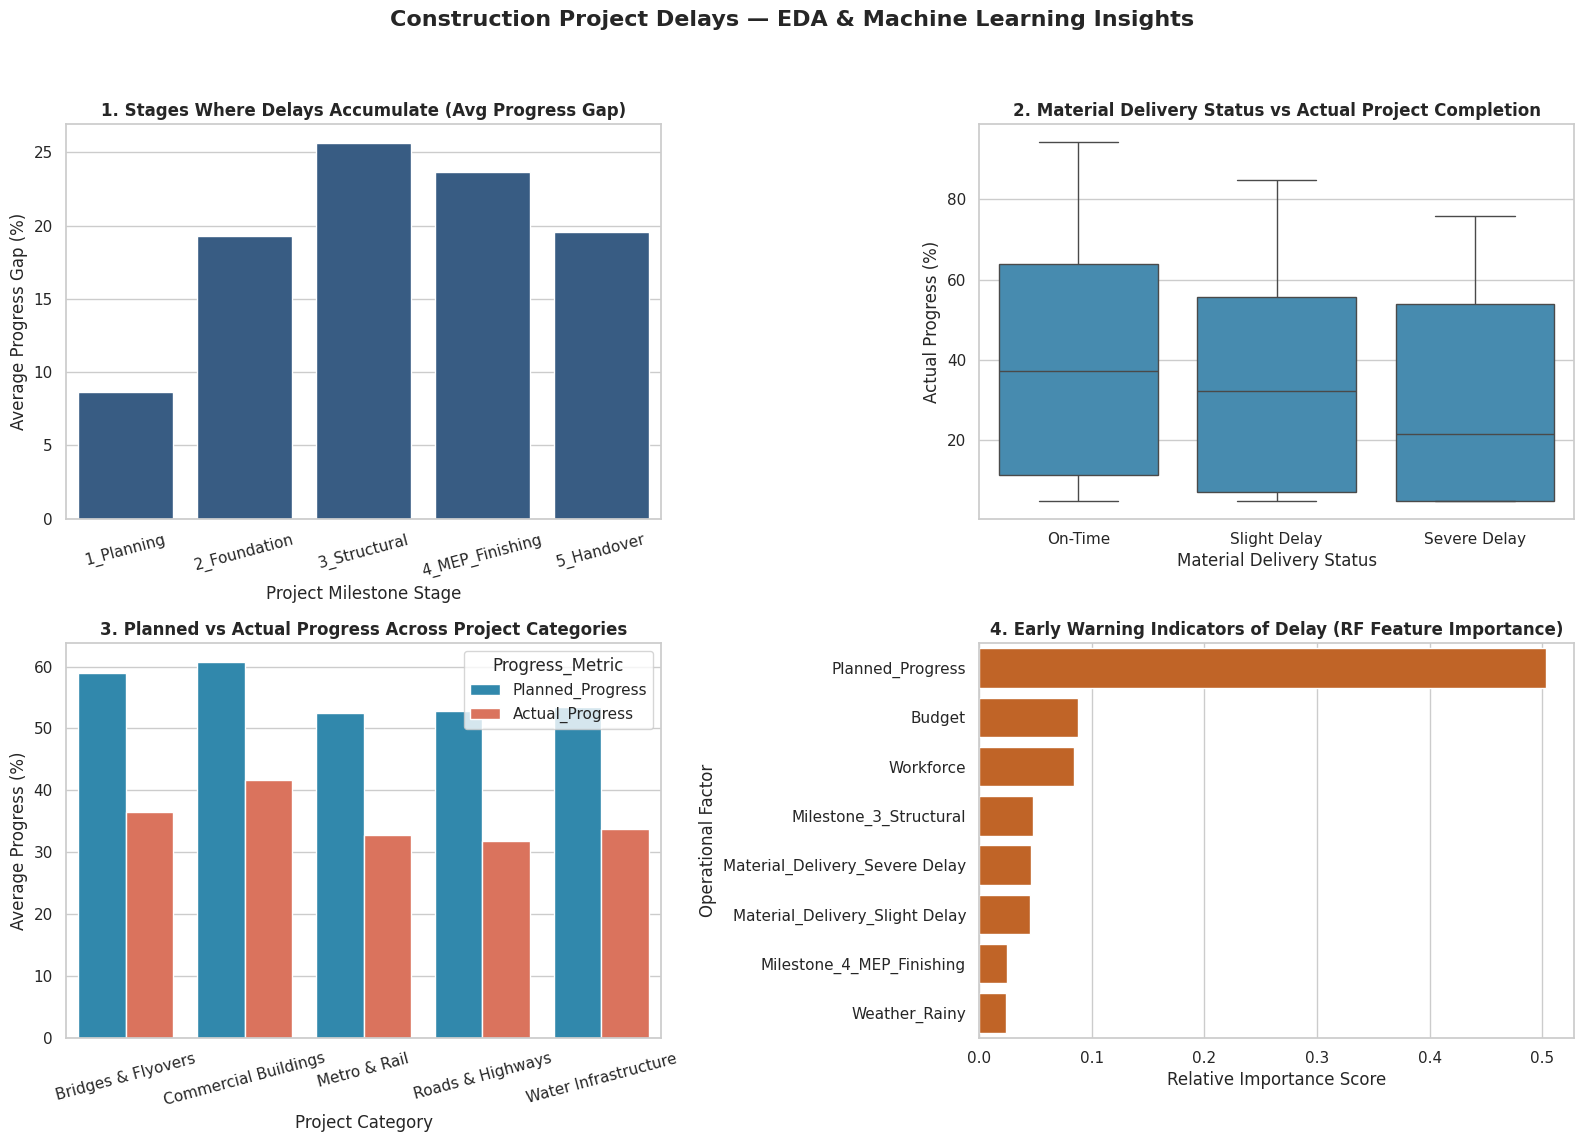

In [5]:
# ========================================================
# TASK 4: CREATE 4 CLEAR VISUALIZATIONS
# ========================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Construction Project Delays — EDA & Machine Learning Insights', fontsize=16, fontweight='bold')

# Visualization 1: Stages Where Delays Accumulate
milestone_order = ['1_Planning', '2_Foundation', '3_Structural', '4_MEP_Finishing', '5_Handover']
sns.barplot(data=df, x='Milestone', y='Progress_Gap', order=milestone_order, ax=axes[0, 0], color='#2b5c8f', errorbar=None)
axes[0, 0].set_title('1. Stages Where Delays Accumulate (Avg Progress Gap)', fontweight='bold')
axes[0, 0].set_ylabel('Average Progress Gap (%)')
axes[0, 0].set_xlabel('Project Milestone Stage')
axes[0, 0].tick_params(axis='x', rotation=15)

# Visualization 2: Material Delays vs Project Completion
mat_order = ['On-Time', 'Slight Delay', 'Severe Delay']
sns.boxplot(data=df, x='Material_Delivery', y='Actual_Progress', order=mat_order, ax=axes[0, 1], color='#3690c0')
axes[0, 1].set_title('2. Material Delivery Status vs Actual Project Completion', fontweight='bold')
axes[0, 1].set_ylabel('Actual Progress (%)')
axes[0, 1].set_xlabel('Material Delivery Status')

# Visualization 3: Compare Different Project Categories
cat_comp = df.groupby('Project_Category')[['Planned_Progress', 'Actual_Progress']].mean().reset_index()
cat_melt = cat_comp.melt(id_vars='Project_Category', var_name='Progress_Metric', value_name='Percentage')
sns.barplot(data=cat_melt, x='Project_Category', y='Percentage', hue='Progress_Metric', ax=axes[1, 0], palette=['#1d91c0', '#ef6548'])
axes[1, 0].set_title('3. Planned vs Actual Progress Across Project Categories', fontweight='bold')
axes[1, 0].set_ylabel('Average Progress (%)')
axes[1, 0].set_xlabel('Project Category')
axes[1, 0].tick_params(axis='x', rotation=15)

# Visualization 4: Early Warning Indicators (Random Forest Feature Importance)
top_features = feature_importances.head(8)
sns.barplot(data=top_features, x='Importance_Score', y='Feature', ax=axes[1, 1], color='#d95f0e')
axes[1, 1].set_title('4. Early Warning Indicators of Delay (RF Feature Importance)', fontweight='bold')
axes[1, 1].set_xlabel('Relative Importance Score')
axes[1, 1].set_ylabel('Operational Factor')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()